In [ ]:
#Importamos las librerias necesarias para el análisis de datos y visualización
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import libpysal


In [4]:
#Cargamos el archivo shapefile de las ocurrencias minerales con el que desarrollaremos el análisis geoespacial.
OcurrenciasMinerales = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Ocurrencias_A-T.shp")
OcurrenciasMinerales.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    505 non-null    int64   
 1   LATITUD     505 non-null    float64 
 2   LONGITUD    505 non-null    float64 
 3   ID_NOM_DEP  505 non-null    str     
 4   IG_EST      505 non-null    str     
 5   IG_DEP      505 non-null    str     
 6   IG_MUN      505 non-null    str     
 7   MINERAL_PP  505 non-null    str     
 8   ENSAMBLE_M  505 non-null    str     
 9   FORMA_OCUR  505 non-null    str     
 10  CLASS_DEPO  505 non-null    str     
 11  ROCA_HUESP  504 non-null    str     
 12  FORMACION_  505 non-null    str     
 13  TIPO_ROCA   505 non-null    str     
 14  EDAD        505 non-null    str     
 15  X_Este      505 non-null    float64 
 16  Y_Norte     505 non-null    float64 
 17  geometry    505 non-null    geometry
dtypes: float64(4), geometry(1), int64(1), str(

In [5]:
OcurrenciasMinerales.head(5)


,OBJECTID,LATITUD,LONGITUD,ID_NOM_DEP,IG_EST,IG_DEP,IG_MUN,MINERAL_PP,ENSAMBLE_M,FORMA_OCUR,CLASS_DEPO,ROCA_HUESP,FORMACION_,TIPO_ROCA,EDAD,X_Este,Y_Norte,geometry
0,1,5.8581,-75.5051,Cementos El Cairo S.A.,Productor - Cielo abierto,05-Antioquia,Abejorral,Calizas,Calcita-CaCO3,Estratiforme,Rocas,ROCA METAMÓRFICA,Grupo Cajamarca,Esquisto,Triásico,841888.193,1139745.879,POINT (841888.193 1139745.879)
1,2,5.7961,-75.4187,El Gallinazo,Productor - Cielo abierto,05-Antioquia,Abejorral,Arcilla_Caolinita,Caolinita-Al2Si2O5(OH)4,Estratiforme,Minerales_Industriales,ROCA METAMÓRFICA,Grupo Cajamarca,Esquisto,Triásico,851442.791,1132864.149,POINT (851442.791 1132864.149)
2,3,5.8059,-75.4171,El Popal,Productor - Subterráneo,05-Antioquia,Abejorral,Oro-Au,Oro-Au,Veta,Sin_Clasificar,ROCA METAMÓRFICA,Grupo Cajamarca,Esquisto,Triásico,851622.602,1133947.763,POINT (851622.602 1133947.763)
3,4,5.8435,-75.3428,El Rebusque,Productor pasado - Subterráneo,05-Antioquia,Abejorral,Oro-Au,Oro-Au,Veta,Sin_Clasificar,ROCA METAMÓRFICA,Grupo Cajamarca,Esquisto,Triásico,859862.897,1138087.896,POINT (859862.897 1138087.896)
4,5,5.8268,-75.4730,EUROCERAMICA S.A.,Productor - Cielo abierto,05-Antioquia,Abejorral,Arcilla_Caolinita,Arcilla-Al2O3·2SiO2·H2O,Estratiforme,Rocas,ROCA SEDIMENTARIA,Formación Abejorral,Conglomerados,Cretácico,845435.507,1136274.605,POINT (845435.507 1136274.605)


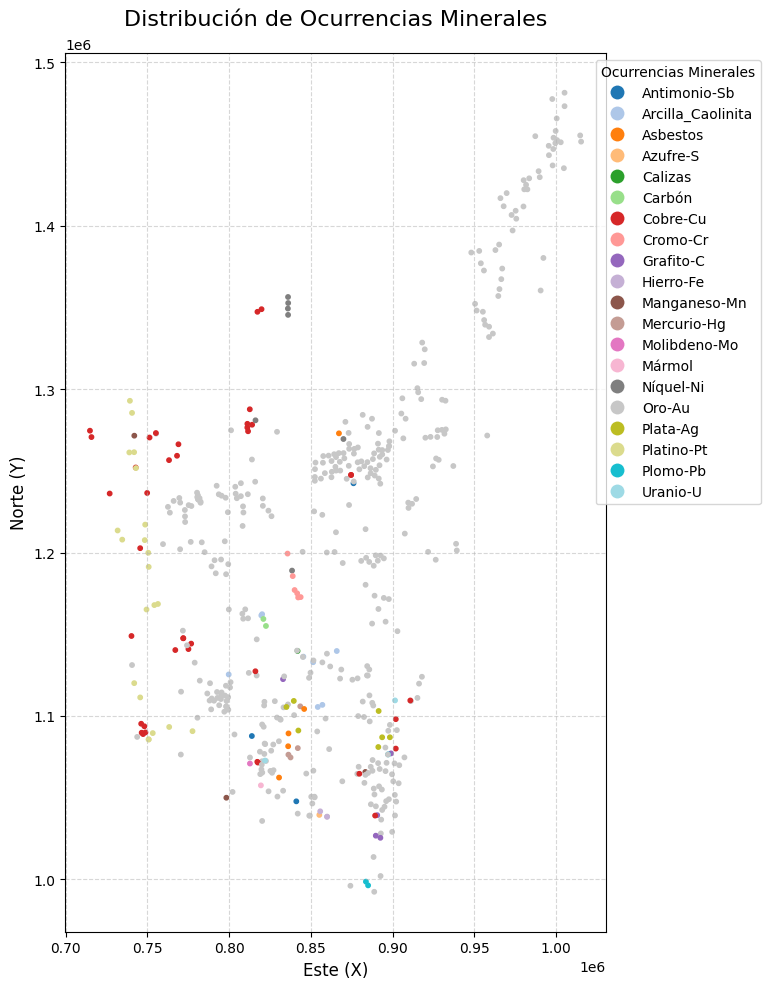

In [7]:
#Vamos a gráficar los puntos categorizados por el tipo de mineral.
fig, ax = plt.subplots(figsize=(10, 10))
OcurrenciasMinerales.plot(
    column="MINERAL_PP",  # Columna para categorizar los puntos
    categorical=True,
    legend=True,
    cmap="tab20",  # Colormap para diferenciar categorías
    markersize=10,
    ax=ax,
    legend_kwds={
        'title': "Ocurrencias Minerales",  # Título de la leyenda
        'loc': 'upper right',    # Ubicación de la leyenda
        'bbox_to_anchor': (1.3, 1) # Mueve la leyenda fuera del mapa si es muy grande
    }
)
#Personalizar el diseño del mapa
ax.set_title('Distribución de Ocurrencias Minerales', fontsize=16, pad=20)
ax.set_xlabel('Este (X)', fontsize=12)
ax.set_ylabel('Norte (Y)', fontsize=12)

#Activar una cuadrícula de fondo
ax.grid(True, linestyle='--', alpha=0.5)

#Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()

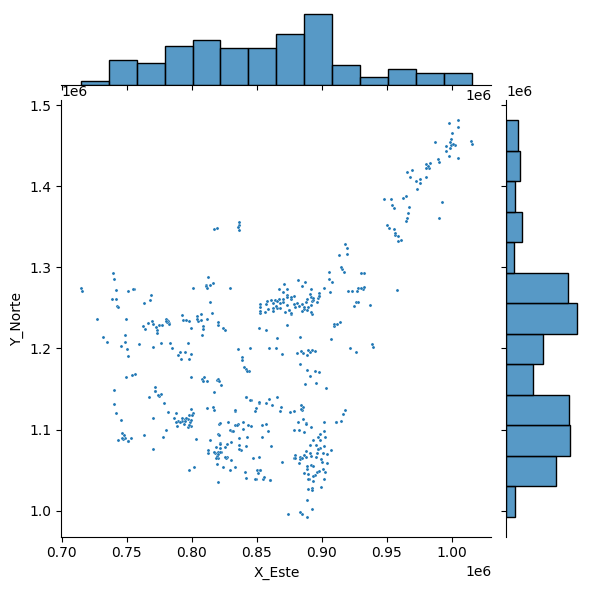

In [8]:
# Generar scatter plot
import seaborn as sbn
sbn.jointplot(x='X_Este', y='Y_Norte', data=OcurrenciasMinerales, s=5)

In [16]:
#Cargamos el archivo shapefile de la geología y las fallas de la zona de trabajo.
Geologia = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Geologia_A-T.shp")
Fallas = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Fallas_A-T.shp")

#Tabla de atributos de la geología
Geologia.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1750 entries, 0 to 1749
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    1750 non-null   int32   
 1   SimboloUC   1750 non-null   str     
 2   N°CartaCo   0 non-null      object  
 3   Descripcio  1750 non-null   str     
 4   Edad        1750 non-null   str     
 5   UGIntegrad  696 non-null    str     
 6   Comentario  2 non-null      str     
 7   GlobalID    1750 non-null   str     
 8   Shape__Are  1750 non-null   float64 
 9   Shape__Len  1750 non-null   float64 
 10  MINX        1750 non-null   float64 
 11  MINY        1750 non-null   float64 
 12  MAXX        1750 non-null   float64 
 13  MAXY        1750 non-null   float64 
 14  CNTX        1750 non-null   float64 
 15  CNTY        1750 non-null   float64 
 16  AREA        1750 non-null   float64 
 17  PERIM       1750 non-null   float64 
 18  HEIGHT      1750 non-null   float64 
 19

<Axes: >

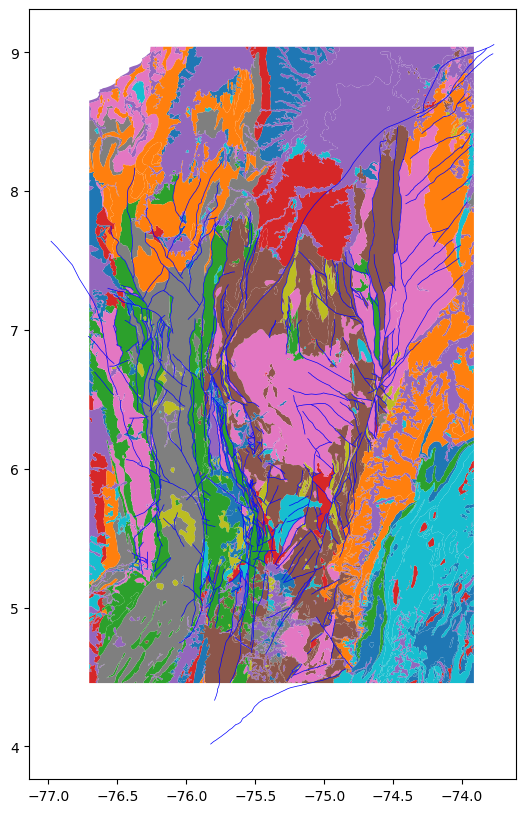

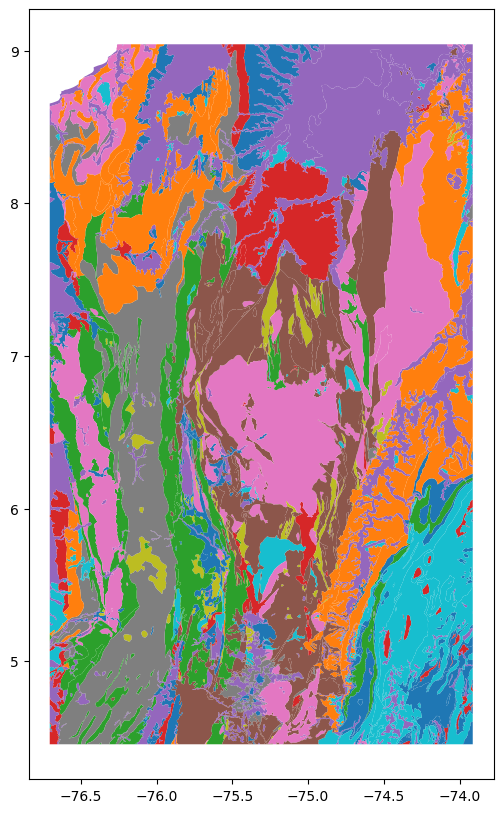

In [12]:
Fallas.plot(ax=Geologia.plot(column="Descripcio", categorical=True, figsize=(10, 10)), color='blue',linewidth=0.5)
Geologia.plot(column="Descripcio", categorical=True, figsize=(10, 10))


In [20]:
#Verificamos el sistema de referencia de cada capa. Todas deben estar en EPSG:21897 para que las medidas de distancia (fallas, KDE, vecinos) sean válidas.
CRS_PROYECTO = "EPSG:21897"
for nombre, capa in [("Ocurrencias", OcurrenciasMinerales), ("Geologia", Geologia), ("Fallas", Fallas)]:
    print(nombre, "->", capa.crs)

Ocurrencias -> EPSG:21897
Geologia -> EPSG:21897
Fallas -> EPSG:21897


In [18]:
#Filtramos la base de datos por Oro (Au), foco del proyecto (~76% de los registros).
col_mineral = "MINERAL_PP"
OcurrenciasAu = OcurrenciasMinerales[
    OcurrenciasMinerales[col_mineral].str.contains("Oro", case=False, na=False)
].copy()
print("Ocurrencias de Au:", len(OcurrenciasAu))

Ocurrencias de Au: 384


In [23]:

#Construimos el Área de Trabajo como un alpha shape a partir de la BD de Ocurrencias.
coords = np.array([(p.x, p.y) for p in OcurrenciasMinerales.geometry])

alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(coords, return_circles=True)

AreaTrabajo = gpd.GeoDataFrame(geometry=[alpha_shape], crs=CRS_PROYECTO)
print("Área de Trabajo (alpha shape):", round(AreaTrabajo.area.iloc[0] / 1e6, 1), "km²")



C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9276\2029091697.py:4: UserWarning: Numba not imported, so alpha shape construction may be slower than expected.
  alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(coords, return_circles=True)


Área de Trabajo (alpha shape): 54205.8 km²


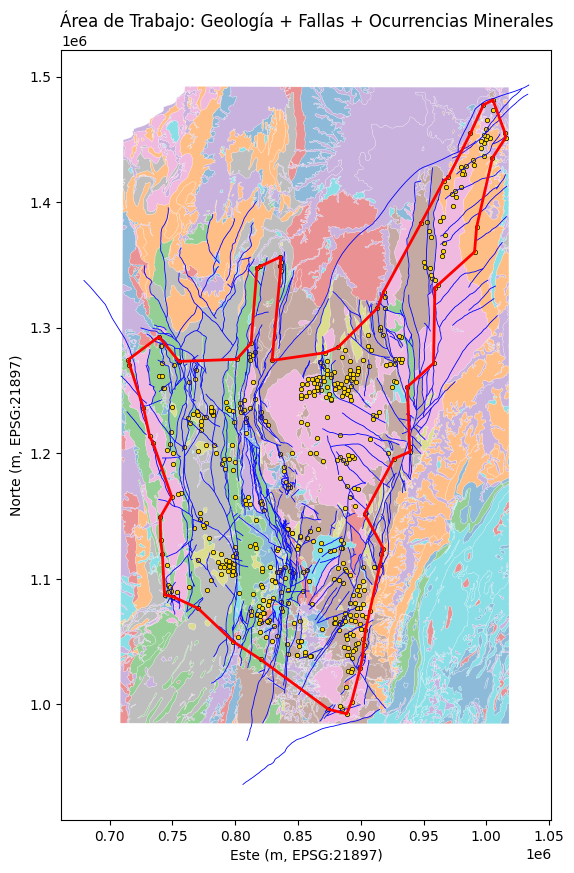

In [30]:
#Gráficamos los 4 elementos que tenemos hasta ahora (BD, Geologia, Fallas, AreaTrabajo).
fig, ax = plt.subplots(figsize=(10, 10))
Geologia.plot(ax=ax,column="Descripcio", categorical=True, edgecolor="white", linewidth=0.3, alpha=0.5)
Fallas.plot(ax=ax, color="blue", linewidth=0.6)
OcurrenciasMinerales.plot(ax=ax, markersize=10, color="gold", edgecolor="k", linewidth=0.5)
AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=2)
ax.set_title("Área de Trabajo: Geología + Fallas + Ocurrencias Minerales")
ax.set_xlabel("Este (m, EPSG:21897)"); ax.set_ylabel("Norte (m, EPSG:21897)")
plt.show()

In [37]:
#Realizamos analisis de centrografía para describir la forma y orientación de la distribución espacial de las ocurrencias minerales.

from pointpats import centrography
from matplotlib.patches import Ellipse, Circle

#Extraemos las coordenadas (x, y) de las ocurrencias de Au como array de NumPy.
CoordsAu = np.array([(p.x, p.y) for p in OcurrenciasAu.geometry])

#Centro medio: el "promedio" espacial de los 384 puntos.
CentroMedio = centrography.mean_center(CoordsAu)

#Distancia estándar: dispersión radial (un radio en metros).
DistStd = centrography.std_distance(CoordsAu)

#Elipse de desviación estándar: semiejes y ángulo de rotación.
SemiMayor, SemiMenor, Rotacion = centrography.ellipse(CoordsAu)

print("Centro medio (x, y):",np.round(CentroMedio, 1))
print("Distancia estándar:", round(DistStd, 0), "m  (~", round(DistStd/1000, 1), "km )")
print("Semiejes elipse:", round(SemiMayor,0), "x", round(SemiMenor,0), "m")
print("Rotación (grados):", round(np.degrees(Rotacion), 1))

Centro medio (x, y): [ 870657.9 1200522.9]
Distancia estándar: 129727.0 m  (~ 129.7 km )
Semiejes elipse: 170775.0 x 68339.0 m
Rotación (grados): 69.2


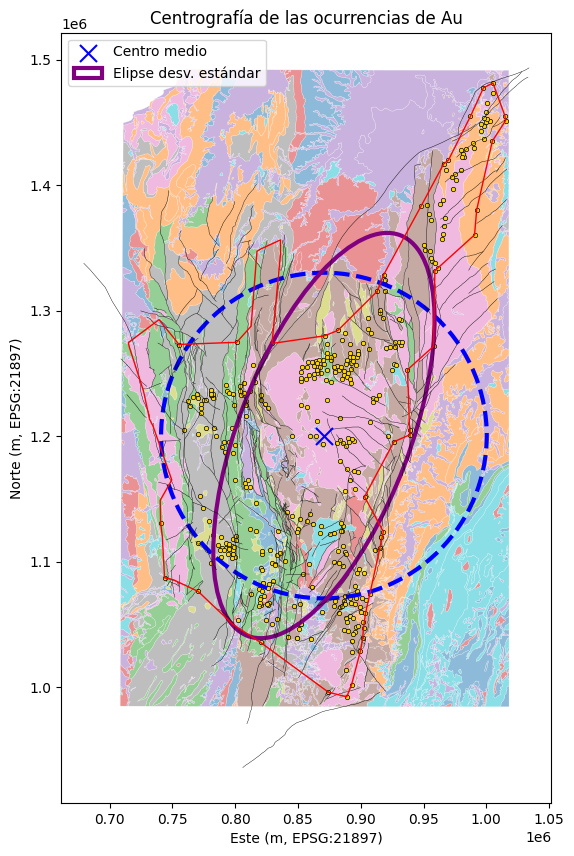

In [46]:
#Visualizamos la centrografía sobre el Área de Trabajo para interpretar la forma y orientación de la distribución de las ocurrencias de Au.
fig, ax = plt.subplots(figsize=(10, 10))
Geologia.plot(ax=ax,column="Descripcio", categorical=True, edgecolor="white", linewidth=0.3, alpha=0.5)
Fallas.plot(ax=ax, color="black", linewidth=0.3)
OcurrenciasAu.plot(ax=ax, markersize=10, color="gold", edgecolor="k", linewidth=0.5)
AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=1)

#Centro medio
ax.scatter(*CentroMedio, color="blue", marker="x", s=150, zorder=5, label="Centro medio")

#Círculo de distancia estándar
ax.add_patch(Circle(CentroMedio, radius=DistStd, edgecolor="blue",
                    facecolor="none", linestyle="--", linewidth=3))

#Elipse de desviación estándar
elipse = Ellipse(xy=CentroMedio, width=2*SemiMayor, height=2*SemiMenor,
                 angle=np.degrees(Rotacion), edgecolor="purple",
                 facecolor="none", linewidth=3, label="Elipse desv. estándar")
ax.add_patch(elipse)

ax.set_title("Centrografía de las ocurrencias de Au")
ax.set_xlabel("Este (m, EPSG:21897)"); ax.set_ylabel("Norte (m, EPSG:21897)")
ax.legend(); plt.show()

Chi²: 1096.0
Grados de libertad: 79
p-valor: 9.302224386173248e-179


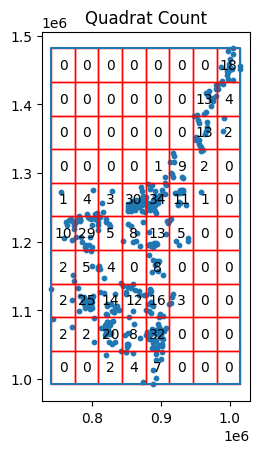

In [49]:
#Análisis de Cuadrantes.

from pointpats import QStatistic

#(~350 km de ancho x ~500 km de alto -> celdas aprox. cuadradas de ~60 km).
QAu = QStatistic(CoordsAu, shape="rectangle", nx=8, ny=10)
QAu.plot()   #mapa de conteos por celda

print("Chi²:", round(QAu.chi2, 1))
print("Grados de libertad:", QAu.df)
print("p-valor:", QAu.chi2_pvalue)

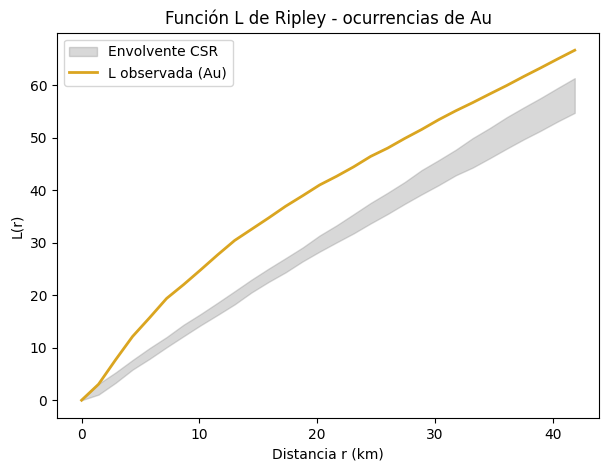

In [50]:
from pointpats import l_test

#Realizamos analisis de K de Ripley para evaluar la presencia de patrones de agrupamiento o dispersión a diferentes escalas espaciales.

Ventana = AreaTrabajo.geometry.iloc[0]   #polígono shapely

ResultL = l_test(
    CoordsAu,
    support=30,             #número de radios r a evaluar
    n_simulations=199,      #199 simulaciones -> banda ~99%
    keep_simulations=True,
    hull=Ventana,           #ventana real para generar el CSR
)

r   = ResultL.support
obs = ResultL.statistic
sims = ResultL.simulations
lo, hi = sims.min(axis=0), sims.max(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(r/1000, lo/1000, hi/1000, color="grey", alpha=0.3, label="Envolvente CSR")
ax.plot(r/1000, obs/1000, color="goldenrod", lw=2, label="L observada (Au)")
ax.set_xlabel("Distancia r (km)"); ax.set_ylabel("L(r)")
ax.legend(); ax.set_title("Función L de Ripley - ocurrencias de Au")
plt.show()

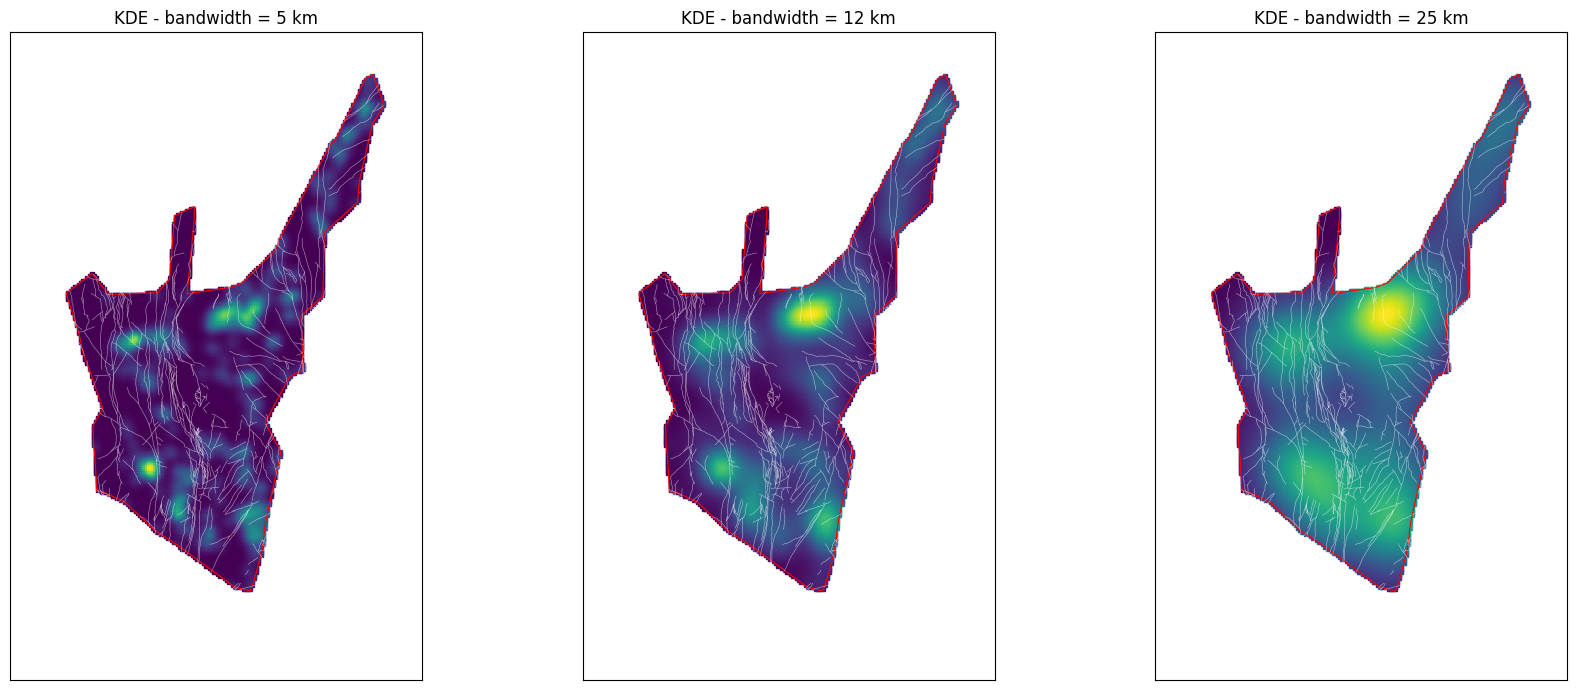

In [53]:
from sklearn.neighbors import KernelDensity
#Construimos una grilla de evaluación que cubra el Área de Trabajo.
#   Resolución de 2 km (2000 m)
xmin, ymin, xmax, ymax = AreaTrabajo.total_bounds
res = 2000
xx, yy = np.meshgrid(
    np.arange(xmin, xmax, res),
    np.arange(ymin, ymax, res),
)
grid_coords = np.column_stack([xx.ravel(), yy.ravel()])

#Recortamos la grilla al alpha shape (solo evaluamos dentro de la ventana).
grid_pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(grid_coords[:,0], grid_coords[:,1]),
    crs=CRS_PROYECTO,
)
dentro = grid_pts.within(AreaTrabajo.geometry.iloc[0])
grid_in = grid_coords[dentro.values]

#Ajustamos el KDE. El bandwidth está en METROS
#   Probamos tres anchos guiados por la escala de Ripley (~10-13 km).
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, bw in zip(axes, [5000, 12000, 25000]):   #5, 12 y 25 km
    kde = KernelDensity(bandwidth=bw, kernel="gaussian")
    kde.fit(CoordsAu)
    #log-densidad -> densidad
    dens = np.exp(kde.score_samples(grid_in))

    sc = ax.scatter(grid_in[:,0], grid_in[:,1], c=dens, cmap="viridis", s=8, marker="s")
    AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=0.8)
    Fallas.plot(ax=ax, color="white", linewidth=0.4, alpha=0.6)
    ax.set_title(f"KDE - bandwidth = {bw/1000:.0f} km")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()